## Introduction

Credit card fraud is a serious problem in modern financial systems. Fraudulent transactions can cause significant financial losses for banks and customers. Detecting these transactions is difficult because fraud cases are very rare compared to normal transactions.

Machine learning techniques can help analyze transaction patterns and identify suspicious activities. By studying transaction data, it is possible to build systems that support fraud detection and assist in making better decisions.

## Problem Statement

The goal of this project is to analyze credit card transaction data and explore patterns that distinguish fraudulent transactions from legitimate ones. This analysis will help in understanding the characteristics of fraud and preparing the data for building a machine learning model that can classify transactions as fraudulent or non-fraudulent.

## Dataset selection

The dataset used in this project is the **Credit Card Fraud Detection Dataset** available on Kaggle.

Dataset Link:
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


## Justification

This dataset is suitable for our project because it contains real-world financial transaction data and clearly labeled classes for fraud detection. It also includes multiple numerical features that allow meaningful analysis and pattern discovery. Additionally, the dataset is widely used in machine learning research, making it reliable for classification and data analysis tasks.

# Initial Data Inspection

In [ ]:
# Install Kaggle API to download datasets directly from Kaggle
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle    # Create a directory to store Kaggle API credentials
!cp kaggle.json ~/.kaggle/  # Copy the Kaggle API key file to the correct directory
!chmod 600 ~/.kaggle/kaggle.json  # Set permissions to secure the API key file

In [ ]:
# Download the Credit Card Fraud dataset from Kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Extract the downloaded ZIP file to access the dataset (creditcard.csv)
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: creditcard.csv          


In [ ]:
#Load the dataset and Display the first 5 rows

import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#  Get basic info about the dataset
# This includes number of rows, columns, and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Show statistical summary of numerical columns
# Includes count, mean, std, min, max, 25%, 50%, 75%
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Check for missing values in each column
# Important to know if we need to clean or fill missing data
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Check for duplicate rows
# This helps to know if there are repeated transactions that should be removed
print("Duplicates:", df.duplicated().sum())

Duplicates: 1081


In [ ]:
# Check the distribution of target classes
# Important to know how imbalanced the dataset is
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


Exploratory Data Analysis (EDA)

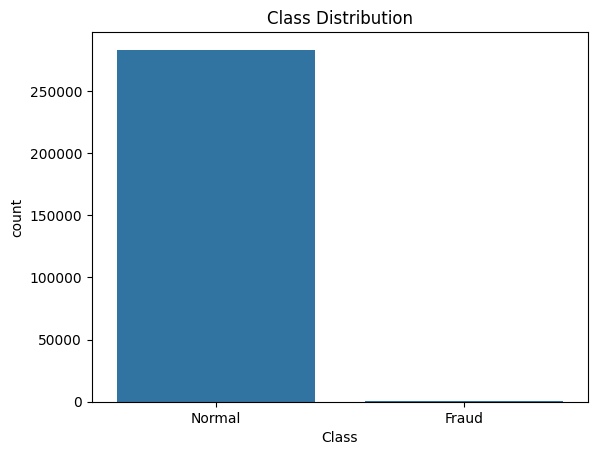

In [ ]:
 #Visualize class distribution
# Shows number of normal vs fraud transactions

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Class'].map({0: 'Normal', 1: 'Fraud'}))
plt.title("Class Distribution")
plt.show()

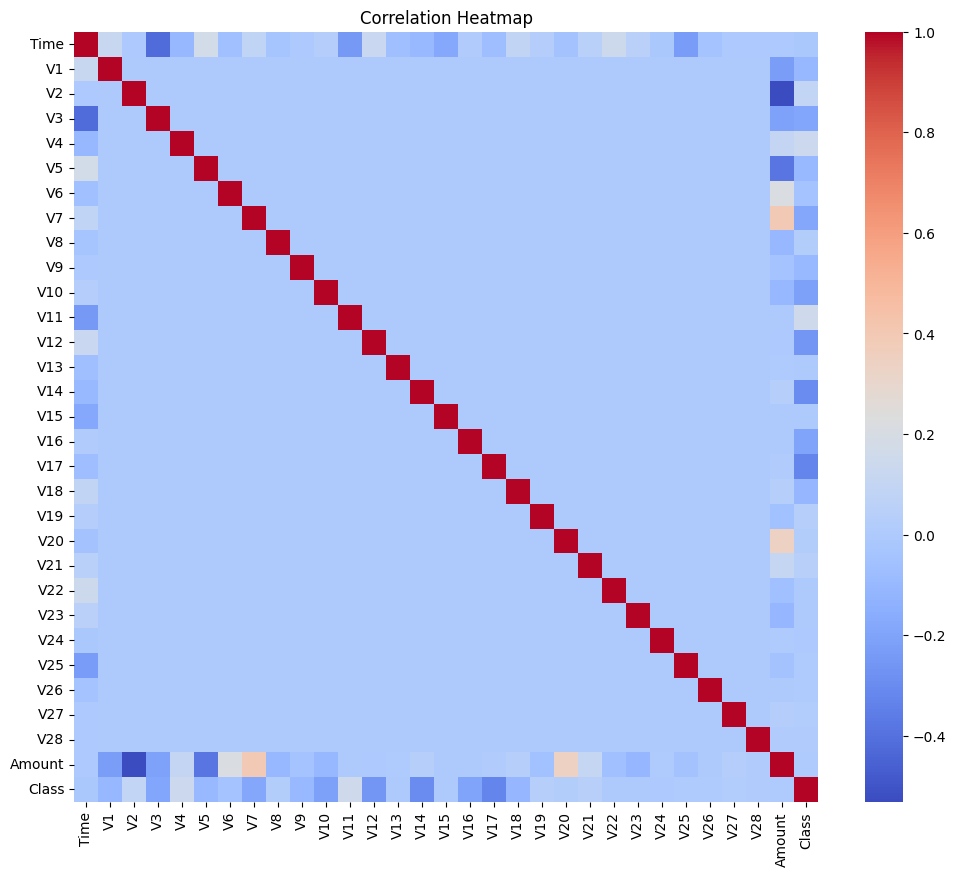

In [ ]:
# Correlation heatmap
# Shows how features relate to each other and to the target variable
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

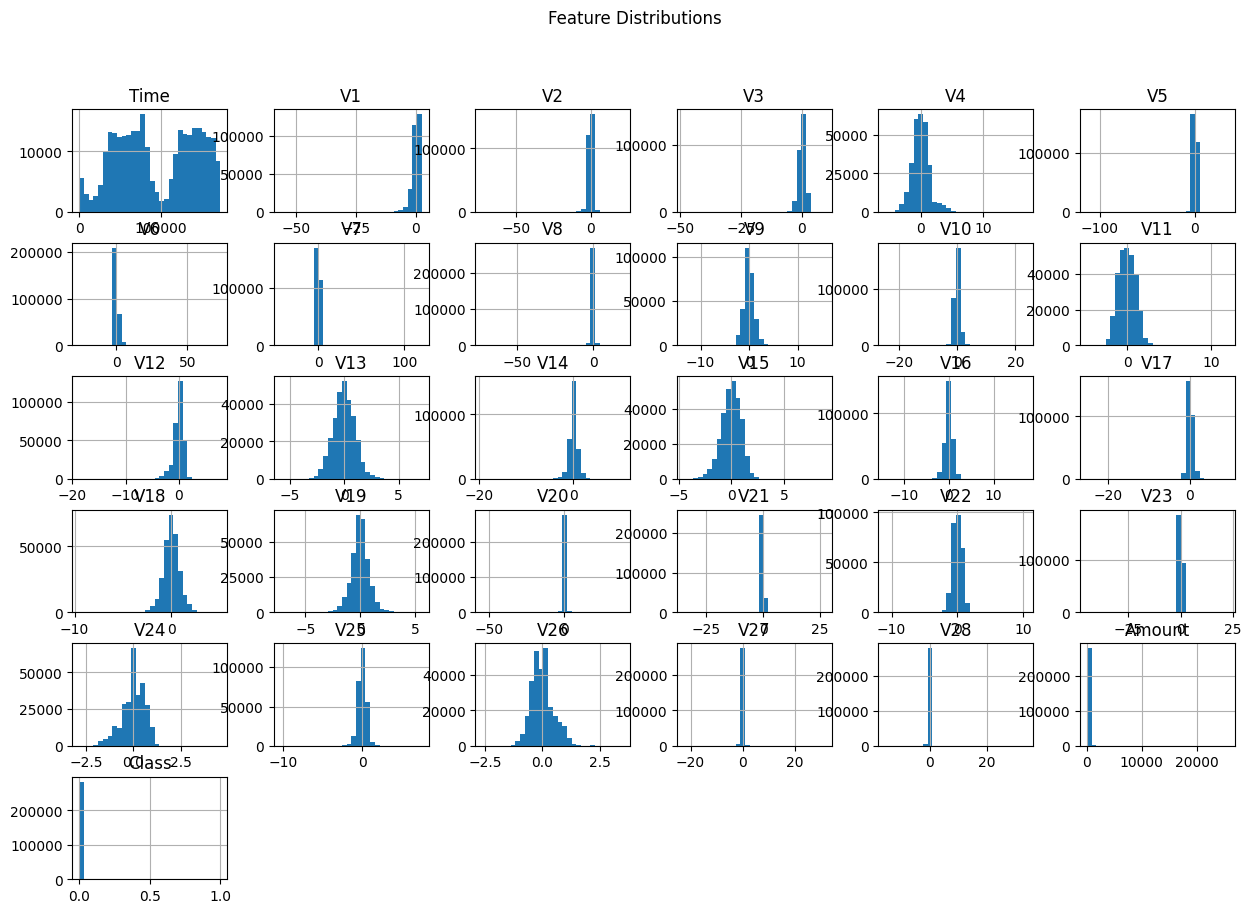

In [ ]:
# Histograms of numerical features
# Helps understand feature distributions and detect skewness or outliers
df.hist(figsize=(15,10), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

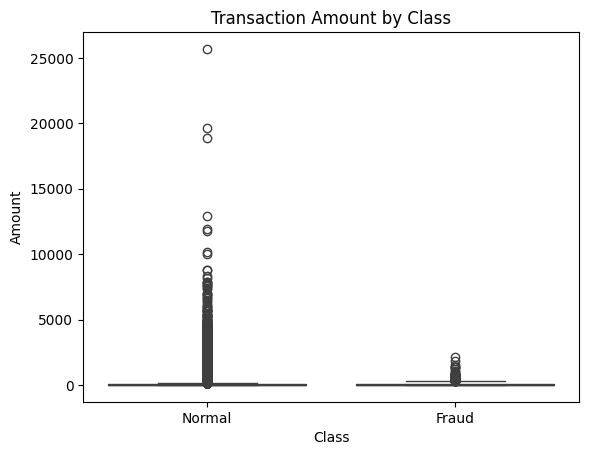

In [ ]:
# Compare the distribution of transaction amounts between normal and fraudulent transactions


sns.boxplot(x=df['Class'].map({0: 'Normal', 1: 'Fraud'}),
            y=df['Amount'])
plt.title("Transaction Amount by Class")
plt.show()

Data Preprocessing & Feature Engineering

In [ ]:
# Remove duplicate rows to prevent repeated transactions from biasing the model and affecting learning accuracy
df = df.drop_duplicates()
print("After removing duplicates:", df.duplicated().sum())

After removing duplicates: 0


In [ ]:
# Remove the Time column since it only represents seconds
# since the first transaction and does not provide useful
# information for fraud detection
df = df.drop("Time", axis=1)

In [ ]:
# Scale the Amount feature to match the scale of the PCA-transformed
# features (V1–V28). This prevents Amount from dominating the model.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

The dataset is now clean, scaled, and ready for machine learning modeling.

Preprocessed Dataset Ready for Modeling



In [ ]:
# Display first 5 rows of preprocessed data
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


In [ ]:
# Display dataset dimensions (number of transactions and number of features)
# to verify the dataset size after preprocessing
df.shape

(283726, 30)

In [ ]:
# Display dataset information including data types and non-null counts
# to confirm that there are no missing values and all features are numeric
# and suitable for machine learning algorithms.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      283726 non-null  float64
 1   V2      283726 non-null  float64
 2   V3      283726 non-null  float64
 3   V4      283726 non-null  float64
 4   V5      283726 non-null  float64
 5   V6      283726 non-null  float64
 6   V7      283726 non-null  float64
 7   V8      283726 non-null  float64
 8   V9      283726 non-null  float64
 9   V10     283726 non-null  float64
 10  V11     283726 non-null  float64
 11  V12     283726 non-null  float64
 12  V13     283726 non-null  float64
 13  V14     283726 non-null  float64
 14  V15     283726 non-null  float64
 15  V16     283726 non-null  float64
 16  V17     283726 non-null  float64
 17  V18     283726 non-null  float64
 18  V19     283726 non-null  float64
 19  V20     283726 non-null  float64
 20  V21     283726 non-null  float64
 21  V22     283726 

In [ ]:
# Check the distribution of the target variable (Class)
# to understand how many transactions are normal (0) and fraudulent (1).
# This helps identify class imbalance in the dataset.
df["Class"].value_counts()

,count
Class,
0,283253
1,473


In [ ]:
# save the dataset for modeling
df.to_csv("creditcard_preprocessed.csv", index=False)

In [ ]:
# Export: Download the cleaned dataset to local system
from google.colab import files
files.download("creditcard_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Key Insights & Challenges

In [ ]:
# Key Insights:
# 1. The dataset is highly imbalanced (fraud ≈ 0.17%), which makes classification challenging.
# 2. The dataset contains no missing values, which simplifies preprocessing and allows direct use of the data for analysis and modeling.
# 3. Transaction amounts vary significantly and require scaling.

# Challenges:
# 1. Imbalanced dataset may bias model toward normal transactions
# 2. Rare fraud cases require careful sampling or advanced techniques
# 3. Some features anonymized (V1-V28), reducing interpretability